In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import os
import statsmodels.formula.api as smf



Default device set to: cuda


In [2]:
dat_file = df = pd.read_csv("Y:/data/Cerebellum/super_cerebellum/sc1/data/s16/sc1_s16.dat", delim_whitespace=True, header=0)
filtered_dat = dat_file[dat_file["runNum"] >= 51]


In [3]:
# collect (prev_task, curr_task) pairs across runs
pairs = []
for _, g in filtered_dat.groupby("runNum"):
    names = g["taskName"].tolist()
    pairs.append(("start",names[0]))  # start of run
    pairs.extend(zip(names[:-1], names[1:]))          # immediate transitions only

length = len(pairs)
print(f"Total number of transitions: {length}")

Total number of transitions: 272


In [4]:
# Build counts matrix
trans_counts = pd.crosstab(
    pd.Series([a for a, b in pairs], name="prev"),
    pd.Series([b for a, b in pairs], name="curr"),
    dropna=False
).fillna(0).astype(int)

In [5]:
tasks = sorted(filtered_dat["taskName"].unique())
trans_counts = trans_counts.reindex(
    index=["start"] + tasks,   # force start to top
    columns=tasks,            
    fill_value=0
)


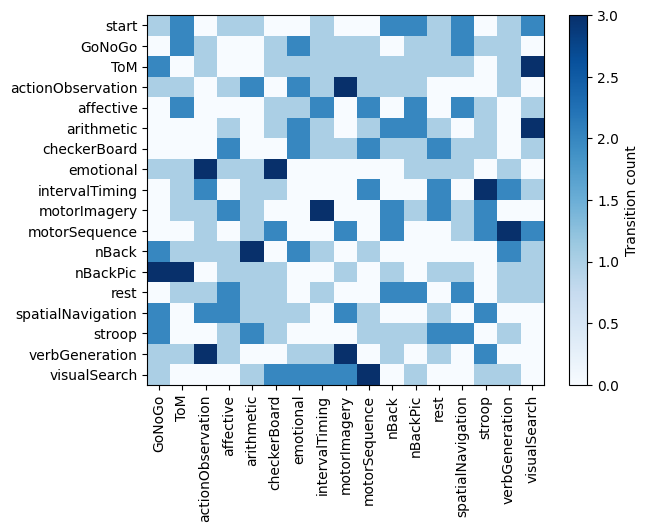

In [6]:
im = plt.imshow(trans_counts, cmap="Blues", aspect="auto")
plt.xticks(range(len(trans_counts.columns)), trans_counts.columns, rotation=90)
plt.yticks(range(len(trans_counts.index)), trans_counts.index)
plt.colorbar(im, label="Transition count")
plt.show()

# Variance decomp

In [7]:
def reorder_mdtb(data, info, filtered_dat, run_map=None):
    """
    Reorder data and info table into the true experimental order.
    
    Params:
    data : np.ndarray
        Array of shape (n_subjects, n_tasks, n_voxels)
    info : pd.DataFrame
        MDTB info dataframe with columns ["run", "task_name", "task_num", ...]
    filtered_dat : pd.DataFrame
        Experimental timing dataframe with columns ["runNum", "taskName", ...]
    run_map : dict, optional
        Mapping from runNum in filtered_dat to run in info, if they differ.
        If None, assumes they are identical. (mdtb dat file has runNum starting from 51)
    Returns
    -------
    data_reordered : np.ndarray
        Same as input data, but rows reordered to match true task order
    info_reordered : pd.DataFrame
        Same as input info, with extra column "task_num_mod" for corrected order
    """
    
    # Default run mapping (identity if not provided)
    if run_map is None:
        run_map = {rn: rn for rn in filtered_dat['runNum'].unique()}
    
    info = info.copy()
    info['task_num_orig'] = -1  # placeholder
    
    # Build dictionary: run -> ordered task list
    true_orders = {}
    for runNum, df_run in filtered_dat.groupby('runNum'):
        run_id = run_map.get(runNum, runNum)
        true_orders[run_id] = df_run['taskName'].tolist()
    
    # Assign corrected task numbers
    for run in info['run'].unique():

        true_order = true_orders[run]
        run_mask = info['run'] == run
        
        for i, tname in enumerate(true_order, start=1):
            mask = run_mask & (info['task_name'] == tname)
            info.loc[mask, 'task_num_orig'] = i
    
    # Sort indices by corrected task order within each run
    sort_idx = []
    for run in sorted(info['run'].unique()):
        run_mask = info['run'] == run
        order = info.loc[run_mask].sort_values('task_num_orig').index
        sort_idx.extend(order)
    
    # Apply reordering
    data_reordered = data[:, sort_idx, :]
    info_reordered = info.loc[sort_idx].reset_index(drop=True)
    
    return data_reordered, info_reordered

In [8]:
def make_prev_cond(cond_vec, part_vec):
    """
    Make a vector of previous global condition IDs (per run).
    First task in each run gets -1.
    """
    prev_vec = np.full_like(cond_vec, -1)  # fill with -1
    for t in range(1, len(cond_vec)):
        if part_vec[t] == part_vec[t-1]:       # same run → use previous cond
            prev_vec[t] = cond_vec[t-1]
        # else → leave as -1 (first task in run)
    return prev_vec

def unique_in_order(x):
    _, idx = np.unique(x, return_index=True)  
    return x[np.sort(idx)]  

def decompose_carryover(data,info,cond_vec,part_vec, include_start=True):
    """
    Decompose data into task, systematic carryover, subject, noise (idosyncratic carryover + movement noise)
    Params:
    data : np.ndarray
        Array of shape (n_subjects, n_tasks, n_voxels)
    info : pd.DataFrame
        MDTB info dataframe with columns ["run", "task_name", "task_num", ...]
    cond_vec : np.ndarray
        Array of shape (n_tasks,) with global condition IDs (task_num)
    part_vec : np.ndarray
        Array of shape (n_tasks,) with partition/run IDs
    Returns
    -------
    """

    prev_vec = make_prev_cond(cond_vec, part_vec)

    if not include_start:
        valid_mask = prev_vec != -1
        info = info.loc[valid_mask].reset_index(drop=True)
        cond_vec = cond_vec[valid_mask]
        part_vec = part_vec[valid_mask]
        prev_vec = prev_vec[valid_mask]
        data = data[:, valid_mask, :]

    
    pair_ids = prev_vec * 1000 + cond_vec
    pair_run_ids = part_vec *1000000 + pair_ids
    unique_run_pairs = unique_in_order(pair_run_ids)
    n_runpairs = len(unique_run_pairs)


    n_subj, n_tasks, n_vox = data.shape
    X = np.full((n_subj,n_runpairs,n_vox),np.nan)

    for pi,pid in enumerate(unique_run_pairs):
        trial_inds = np.where(pair_run_ids == pid)[0]
        X[:, pi, :] = np.mean(data[:, trial_inds, :], axis=1)

    pair_prev = (unique_run_pairs % 1_000_000) // 1000
    pair_curr = (unique_run_pairs % 1_000_000) % 1000
    pair_run  = unique_run_pairs // 1_000_000

    Y = X.reshape(n_subj*n_runpairs, n_vox)

    subj_vec = np.repeat(np.arange(n_subj), n_runpairs)
    curr_vec = np.tile(pair_curr, n_subj)
    prev_vec = np.tile(pair_prev, n_subj)
    run_vec = np.tile(pair_run, n_subj)

    YY = Y @ Y.T

    same_subj   = subj_vec[:, None] == subj_vec[None, :]
    same_run    = run_vec[:, None] == run_vec[None, :]
    same_curr   = curr_vec[:, None] == curr_vec[None, :]
    same_prev   = prev_vec[:, None] == prev_vec[None, :]

    # --- Group/task (cross-subject, any prev) ---
    mask_group = ~same_subj & same_curr # sigma(group)

    # --- Carry-over (cross-subject, same task) --- (the sum of carry and non-carry is the group effect)
    mask_carry    = ~same_subj & same_curr & same_prev # sigma(task) + sigma (carry)
    mask_noncarry = ~same_subj & same_curr & ~same_prev # sigma (task)

    # --- Subject-specific ---
    mask_within_acrossruns = same_subj & ~same_run & same_curr # sigma (task) + sigma (Carry) + sigma (subject)
    mask_within_samerun  = same_subj & same_run & same_curr # sigma (task) + sigma (carry) + sigma (subject) +sigma (noise)
    
    v_group   = np.nanmean(YY[mask_group])
    v_carry   = np.nanmean(YY[mask_carry])
    v_noncarry= np.nanmean(YY[mask_noncarry])
    v_within_acrossruns = np.nanmean(YY[mask_within_acrossruns])
    v_within_samerun    = np.nanmean(YY[mask_within_samerun])

    v_e = v_within_samerun - v_within_acrossruns
    v_g = v_group
    v_s = v_within_acrossruns - v_group
    v_c = v_carry - v_noncarry
    v_t = v_noncarry

    total = v_e + v_s  + v_c + v_t
    
    print(f"proportions: task(non-carry): {v_t / total:.3f}, carry: {v_c / total:.3f}, subject: {v_s / total:.3f}, noise: {v_e / total:.3f}")

    ## --- Subject-specific carry-over (within-subject, same task) ---
    v_c_per_subj = np.empty(n_subj)
    for s in range(n_subj):
        row = (subj_vec == s)
        # pairs where one side is subject s and the other is not s
        edges_s = (row[:, None] & ~row[None, :]) | (~row[:, None] & row[None, :])

        m_c  = mask_carry    & edges_s
        m_nc = mask_noncarry & edges_s

        v_c_per_subj[s] = np.nanmean(YY[m_c]) - np.nanmean(YY[m_nc])

    return v_c_per_subj

# Cerebellum

In [9]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)

# needed to map runs from the old(data files) to the new(info_mdtb_1_run)
run_map = {51: 1,52: 2,53: 3,54: 4,55: 5,56: 6,57: 7,58: 8,59: 9,60: 10,61: 11,62: 12,63: 13,64: 14,65: 15,66: 16,}

data_mdtb_s1_run_reordered, info_mdtb_1_run_reordered = reorder_mdtb(
    data_mdtb_s1_run,
    info_mdtb_1_run,
    filtered_dat,
    run_map= run_map
)

cond_vec = info_mdtb_1_run_reordered["task_num"].values   # global condition ID
part_vec  = info_mdtb_1_run_reordered["run"].values  


In [10]:
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False
)

print("Including start of run")


subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True
)


proportions: task(non-carry): 0.024, carry: 0.004, subject: 0.066, noise: 0.906
Including start of run
proportions: task(non-carry): 0.027, carry: 0.004, subject: 0.073, noise: 0.895


In [61]:
from scipy.stats import ttest_1samp,ttest_rel
t, p = ttest_1samp(subject_carryover, 0.0)
print(f"Subject carry-over t={t:.3f}, p={p:.3e}")

t_start, p_start = ttest_1samp(subject_carryover_start, 0.0)
print(f"Subject carry-over (including start) t={t_start:.3f}, p={p_start:.3e}")

t_2, p_2 = ttest_rel(subject_carryover, subject_carryover_start)
print(f"paired t-test (with vs without start): t={t_2:.3f}, p={p_2:.3g}")

Subject carry-over t=6.731, p=7.252e-07
Subject carry-over (including start) t=6.504, p=1.230e-06
paired t-test (with vs without start): t=-0.233, p=0.817


# Cortex

In [62]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)

# needed to map runs from the old(data files) to the new(info_mdtb_1_run)
run_map = {51: 1,52: 2,53: 3,54: 4,55: 5,56: 6,57: 7,58: 8,59: 9,60: 10,61: 11,62: 12,63: 13,64: 14,65: 15,66: 16,}

data_mdtb_s1_run_reordered, info_mdtb_1_run_reordered = reorder_mdtb(
    data_mdtb_s1_run,
    info_mdtb_1_run,
    filtered_dat,
    run_map= run_map
)

cond_vec = info_mdtb_1_run_reordered["task_num"].values   # global condition ID
part_vec  = info_mdtb_1_run_reordered["run"].values  


In [63]:
subject_carryover = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=False
)

print("Including start of run")

subject_carryover_start = decompose_carryover(
    data_mdtb_s1_run_reordered,
    info_mdtb_1_run_reordered,
    cond_vec,
    part_vec, include_start=True
)


proportions: task(non-carry): 0.126, carry: 0.009, subject: 0.176, noise: 0.690
Including start of run
proportions: task(non-carry): 0.135, carry: 0.010, subject: 0.188, noise: 0.667


In [64]:
from scipy.stats import ttest_1samp,ttest_rel
t, p = ttest_1samp(subject_carryover, 0.0)
print(f"Subject carry-over t={t:.3f}, p={p:.3e}")

t_start, p_start = ttest_1samp(subject_carryover_start, 0.0)
print(f"Subject carry-over (including start) t={t_start:.3f}, p={p_start:.3e}")

t_2, p_2 = ttest_rel(subject_carryover, subject_carryover_start)
print(f"paired t-test (with vs without start): t={t_2:.3f}, p={p_2:.3g}")

Subject carry-over t=12.351, p=1.240e-11
Subject carry-over (including start) t=13.366, p=2.496e-12
paired t-test (with vs without start): t=-6.917, p=4.73e-07
